<a href="https://colab.research.google.com/github/aaharini/Uber-case-study-project-in-python/blob/main/uber_case_study_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
df = pd.read_csv('/content/sample_data/uber-data (8).csv')

In [35]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,07-11-2016 11:51,07-11-2016 13:00
1,867,Airport,1.0,Trip Completed,07-11-2016 17:57,07-11-2016 18:47
2,1807,City,1.0,Trip Completed,07-12-2016 09:17,07-12-2016 09:58
3,2532,Airport,1.0,Trip Completed,07-12-2016 21:08,07-12-2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33,13-07-2016 09:25


In [36]:
df.shape

(6745, 6)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [38]:
df.describe(include = "all")

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
count,6745.000000,6745,4095.000000,6745,6745,2831
unique,NaN,2,NaN,3,4016,2282
top,NaN,City,NaN,Trip Completed,15-07-2016 19:19,13-07-2016 08:53
freq,NaN,3507,NaN,2831,8,5
mean,3384.644922,NaN,149.501343,NaN,NaN,NaN
std,1955.099667,NaN,86.051994,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,1691.000000,NaN,75.000000,NaN,NaN,NaN
50%,3387.000000,NaN,149.000000,NaN,NaN,NaN
75%,5080.000000,NaN,224.000000,NaN,NaN,NaN


In [39]:
city_pickup = df[df['Pickup point'] == 'Airport']
display(city_pickup.head())

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,07-11-2016 11:51,07-11-2016 13:00
1,867,Airport,1.0,Trip Completed,07-11-2016 17:57,07-11-2016 18:47
3,2532,Airport,1.0,Trip Completed,07-12-2016 21:08,07-12-2016 22:03
5,3879,Airport,1.0,Trip Completed,13-07-2016 21:57,13-07-2016 22:28
6,4270,Airport,1.0,Trip Completed,14-07-2016 06:15,14-07-2016 07:13


In [40]:
city_pickup = df[df['Pickup point'] == 'City']
display(city_pickup.head())

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
2,1807,City,1.0,Trip Completed,07-12-2016 09:17,07-12-2016 09:58
4,3112,City,1.0,Trip Completed,13-07-2016 08:33,13-07-2016 09:25
8,6248,City,1.0,Trip Completed,15-07-2016 17:57,15-07-2016 18:50
9,267,City,2.0,Trip Completed,07-11-2016 06:46,07-11-2016 07:25
11,1983,City,2.0,Trip Completed,07-12-2016 12:30,07-12-2016 12:57


In [41]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, format='mixed')
df['request_hour'] = df['Request timestamp'].dt.hour
display(df.head())

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,request_hour
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,07-11-2016 13:00,11
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,07-11-2016 18:47,17
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,07-12-2016 09:58,9
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,07-12-2016 22:03,21
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:00,13-07-2016 09:25,8


In [42]:
def get_timelot(hour):
    if hour <= 4:
        return 'dawn'
    elif hour <= 9:
        return 'early morning'
    elif hour < 16:
        return 'noon'
    elif hour < 21:
        return 'late evening'
    else:
        return 'night'

df['timelot'] = df['request_hour'].apply(get_timelot)
display(df.head())


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,request_hour,timelot
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,07-11-2016 13:00,11,noon
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,07-11-2016 18:47,17,late evening
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,07-12-2016 09:58,9,early morning
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,07-12-2016 22:03,21,night
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:00,13-07-2016 09:25,8,early morning


In [43]:
display(df['timelot'].value_counts())

,count
timelot,
early morning,2103
late evening,2052
noon,1065
night,947
dawn,578


In [44]:
df['Status'].unique()

array(['Trip Completed', 'Cancelled', 'No Cars Available'], dtype=object)

In [45]:
available_cabs = df[df['Status'] == 'Trip Completed'].shape[0]
not_available_cabs = df[df['Status'].isin(['Cancelled', 'No Cars Available'])].shape[0]

cab_status_data = pd.DataFrame({
    'Category': ['Cab Available', 'Cab Not Available'],
    'Count': [available_cabs, not_available_cabs]
})

display(cab_status_data)

,Category,Count
0,Cab Available,2831
1,Cab Not Available,3914


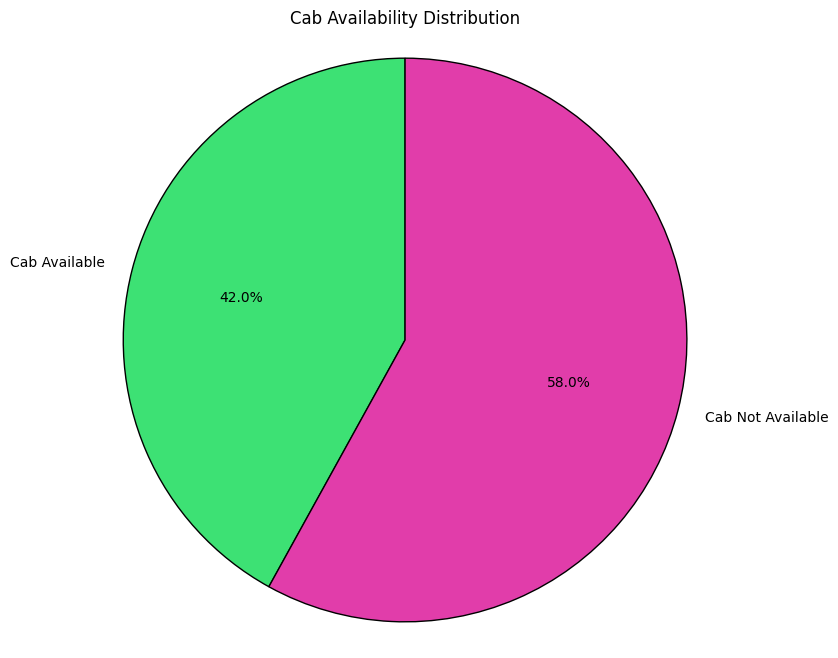

In [46]:
plt.figure(figsize=(8, 8))
colors = ['#3DE174', '#E13DAA']
plt.pie(cab_status_data['Count'], labels=cab_status_data['Category'], autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'}, colors=colors)
plt.title('Cab Availability Distribution')
plt.axis('equal')
plt.show()

/tmp/ipykernel_4458/1349427651.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Status', y='Count', data=status_counts, palette='viridis')


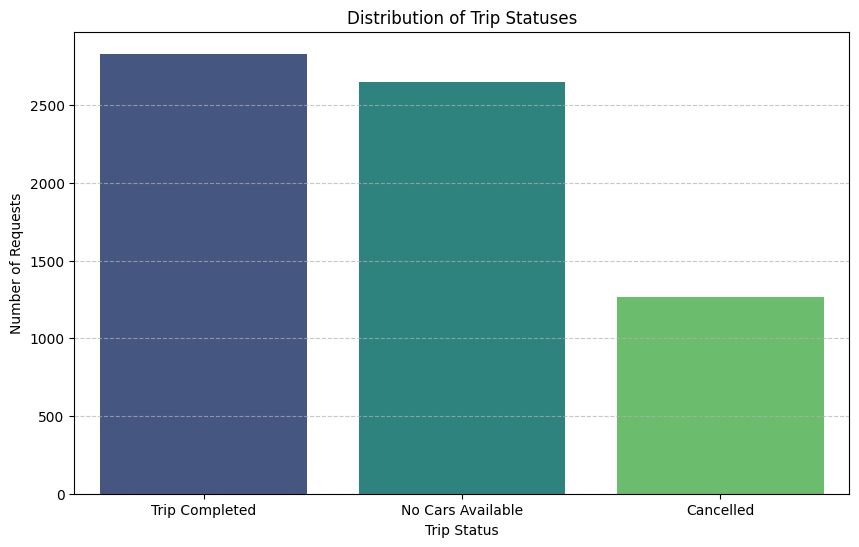

In [47]:
status_counts = df['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Status', y='Count', data=status_counts, palette='viridis')
plt.title('Distribution of Trip Statuses')
plt.xlabel('Trip Status')
plt.ylabel('Number of Requests')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

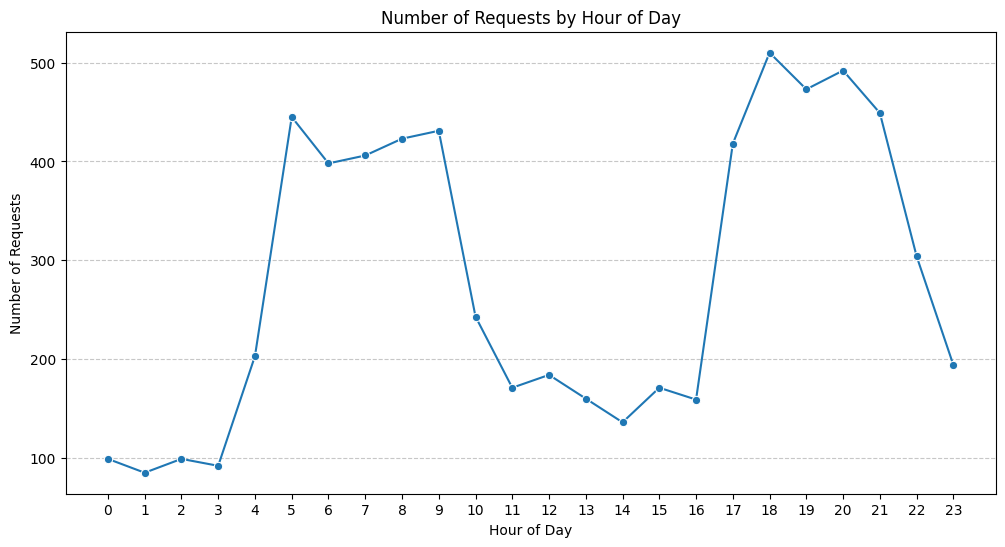

In [48]:
requests_by_hour = df['request_hour'].value_counts().sort_index().reset_index()
requests_by_hour.columns = ['Hour', 'Number of Requests']

plt.figure(figsize=(12, 6))
sns.lineplot(x='Hour', y='Number of Requests', data=requests_by_hour, marker='o')
plt.title('Number of Requests by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

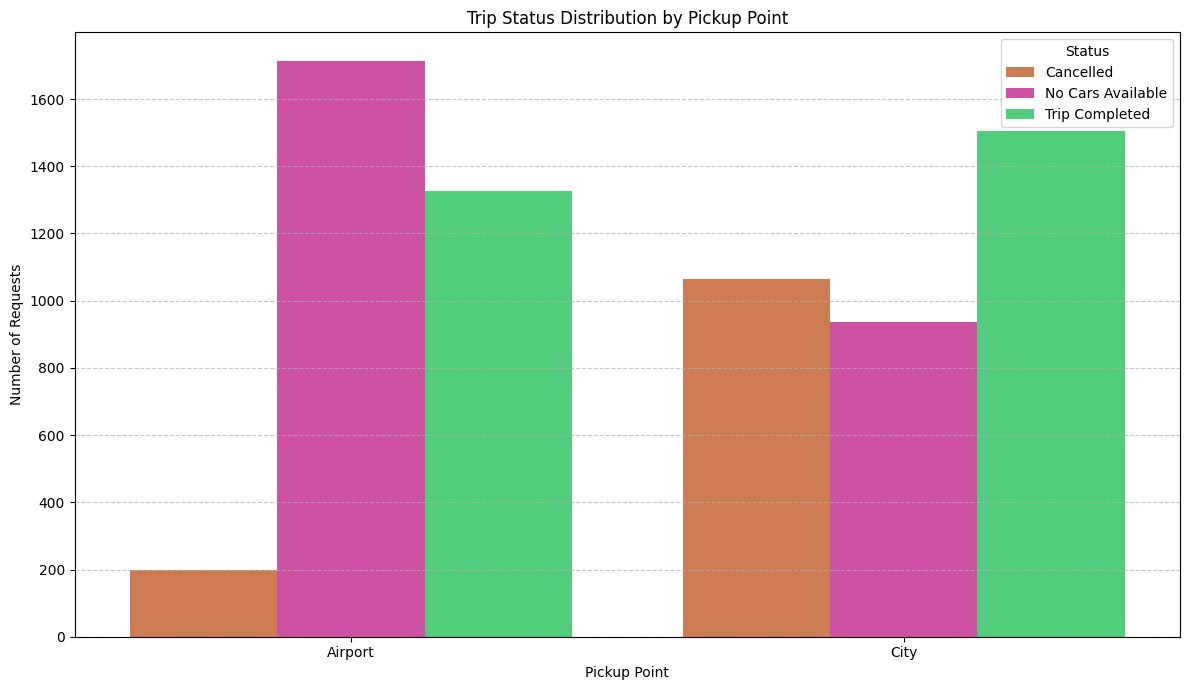

In [49]:
status_by_pickup = df.groupby(['Pickup point', 'Status']).size().unstack(fill_value=0).reset_index()
status_by_pickup_melted = status_by_pickup.melt(id_vars='Pickup point', var_name='Status', value_name='Count')

# Define the custom color palette
custom_palette = {'Trip Completed': '#3DE174', 'Cancelled': '#E1743D', 'No Cars Available': '#E13DAA'}

plt.figure(figsize=(12, 7))
sns.barplot(x='Pickup point', y='Count', hue='Status', data=status_by_pickup_melted, palette=custom_palette)
plt.title('Trip Status Distribution by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

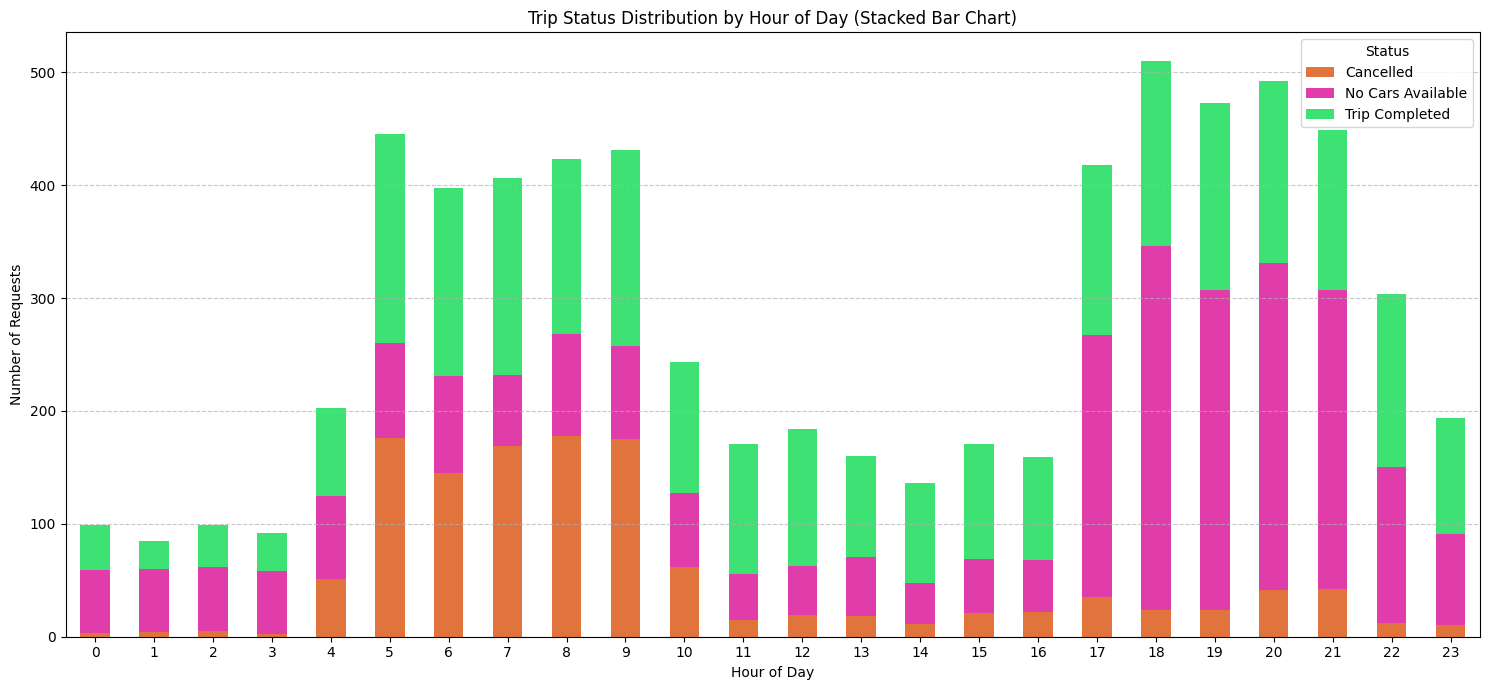

In [50]:
status_by_hour = df.groupby(['request_hour', 'Status']).size().unstack(fill_value=0)

status_by_hour.plot(kind='bar', stacked=True, figsize=(15, 7), color=[custom_palette[col] for col in status_by_hour.columns])
plt.title('Trip Status Distribution by Hour of Day (Stacked Bar Chart)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

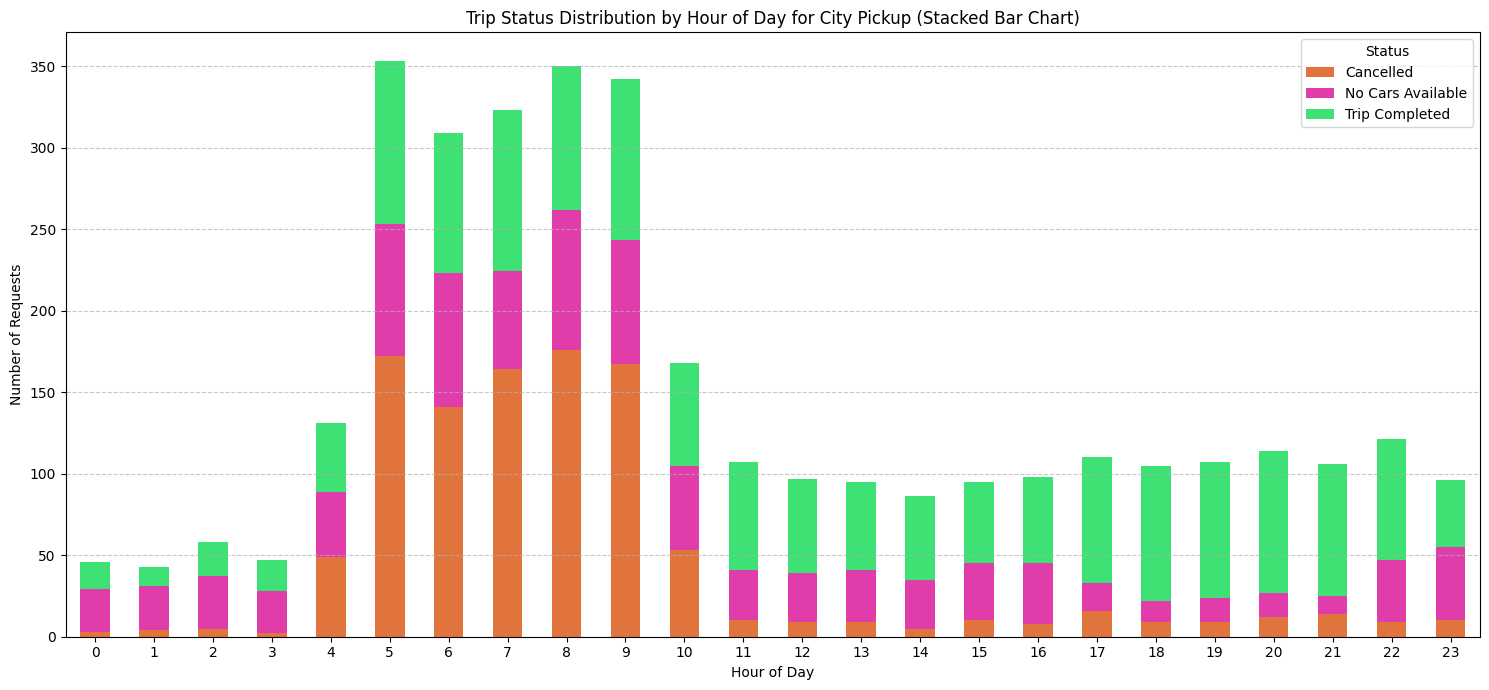

In [51]:
city_df = df[df['Pickup point'] == 'City']

status_by_hour_city = city_df.groupby(['request_hour', 'Status']).size().unstack(fill_value=0)

status_by_hour_city.plot(kind='bar', stacked=True, figsize=(15, 7), color=[custom_palette[col] for col in status_by_hour_city.columns])
plt.title('Trip Status Distribution by Hour of Day for City Pickup (Stacked Bar Chart)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

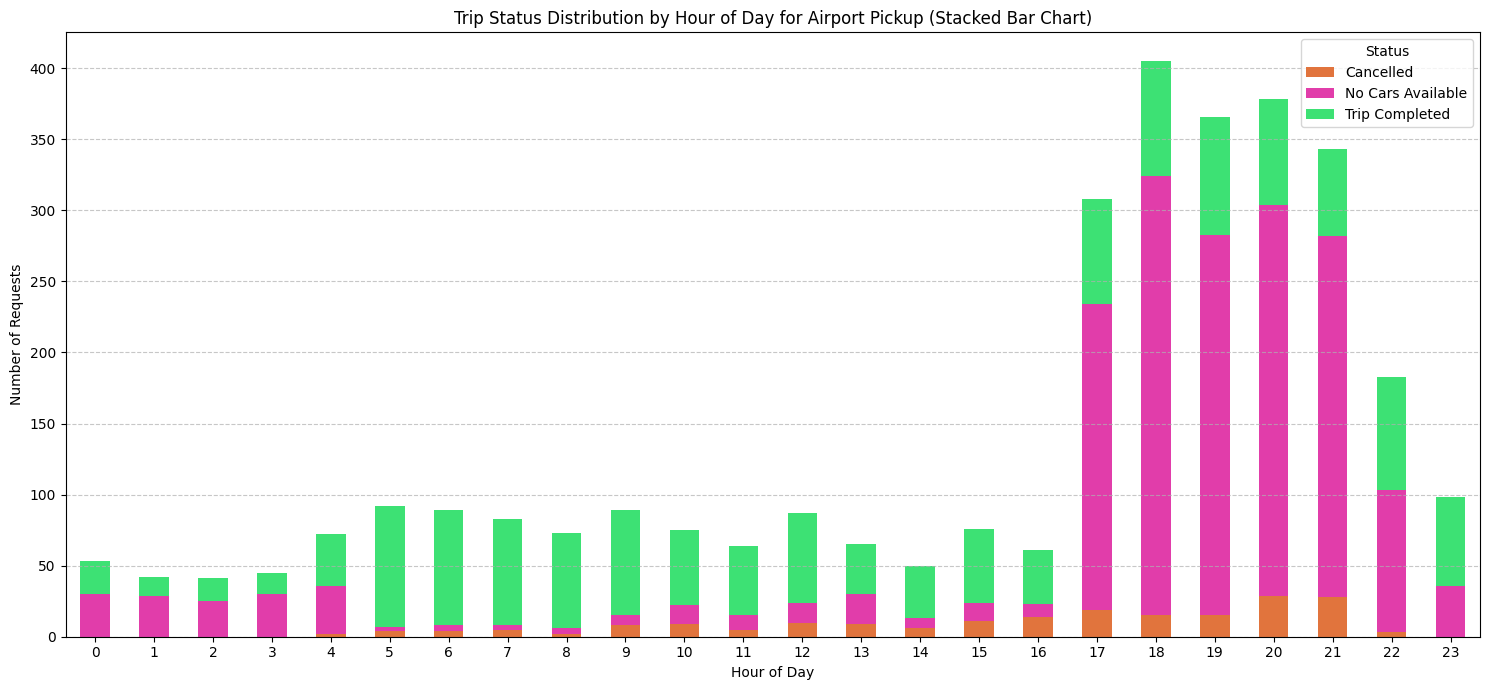

In [52]:
airport_df = df[df['Pickup point'] == 'Airport']

status_by_hour_airport = airport_df.groupby(['request_hour', 'Status']).size().unstack(fill_value=0)

status_by_hour_airport.plot(kind='bar', stacked=True, figsize=(15, 7), color=[custom_palette[col] for col in status_by_hour_airport.columns])
plt.title('Trip Status Distribution by Hour of Day for Airport Pickup (Stacked Bar Chart)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()